# 221 — How far back is each MHC gene detectable, and by what?

**Question:** the midi run searched 221 extended-MHC proteins against nine proteomes
spanning 100 to 2,000 million years of divergence. How many are still detectable in each,
and does the answer depend on which part of the region a gene sits in?

The MHC is the right place to ask because it holds its own controls. Class I and class II
are jawed-vertebrate inventions; class III, sitting between them, is complement, TNF and
heat-shock genes with orthologs running back to bacteria. If a detection curve falls off
with divergence for the whole region equally, that is the tool. If class I and class II fall
off where the genes stop existing and class III does not, that is the biology, and the tool
is reading it correctly.

Every count below is reported on **two** metrics side by side, never one:

| metric | rule | what it asks |
|---|---|---|
| `delimited` | the run's own `is_tp`: family matches and the interval reaches IoU ≥ 0.5 | did the call get the boundary right |
| `covered` | `best_cover` ≥ 0.5: a call overlaps at least half the true domain | did the call reach the domain at all |

The reason for carrying both is [223](./223_mhc_platform_vs_ig_domain.ipynb), which shows
that under IoU, delimitability is a property of the **target database** rather than of the
tool: a domain can only clear IoU ≥ 0.5 if its length fraction inside its protein is ≥ 0.5,
or if the target proteome happens to contain a protein carrying that Pfam family on its own,
from which a tight boundary can be inherited. A metric that behaves that way cannot be the
only one a cross-tool comparison runs on.

An earlier version of this notebook said the kmerseek deficit was "boundary tightness, not
sensitivity". §1b shows that is wrong. Recomputing under `covered` moves kmerseek by nine
genes out of a ninety-three-gene shortfall, and the ratio to the baselines is unchanged to
two decimal places. The 223 mechanism is real, and it does not rescue kmerseek here.

Read [220](./220_mhc_region_map_and_coverage.ipynb) first for the region map and the
reachability denominator.

Two denominators are computed here from the run's own tables and never read from the
pipeline's summary metrics. `recall_reachable` and `n_reachable_instances` in
`all_domain_metrics.parquet` are not used anywhere in this notebook or in
[222](./222_mhc_synteny_target_side.ipynb): under the `swissprot` truth set the `pfam_id`
column holds a 12-level feature type rather than a Pfam family, which makes the reachability
join vacuous and pins the denominator at a constant. That file is touched once below, to
read `interval_semantics`, and only after filtering to `truth_set == "pfam"`.

MHC-window query genes : 221
arms scored            : 413 (404 kmerseek)
alignment-semantics baselines: 8   motif-semantics: ['folddisco']

mouse, genes reached under each metric (kmerseek pooled over all arms):
shape: (10, 5)
┌───────────────────┬───────────┬─────────┬─────┬───────────┐
│ tool              ┆ delimited ┆ covered ┆ gap ┆ semantics │
│ ---               ┆ ---       ┆ ---     ┆ --- ┆ ---       │
│ str               ┆ u32       ┆ u32     ┆ u32 ┆ str       │
╞═══════════════════╪═══════════╪═════════╪═════╪═══════════╡
│ reseek            ┆ 171       ┆ 217     ┆ 46  ┆ alignment │
│ prostt5           ┆ 181       ┆ 213     ┆ 32  ┆ alignment │
│ foldseek          ┆ 188       ┆ 215     ┆ 27  ┆ alignment │
│ mmseqs2_seqseq    ┆ 196       ┆ 219     ┆ 23  ┆ alignment │
│ hhblits           ┆ 205       ┆ 219     ┆ 14  ┆ alignment │
│ hmmer3_phmmer     ┆ 204       ┆ 218     ┆ 14  ┆ alignment │
│ mmseqs2_iterative ┆ 205       ┆ 219     ┆ 14  ┆ alignment │
│ hmmer3_jackhmmer  ┆ 204    

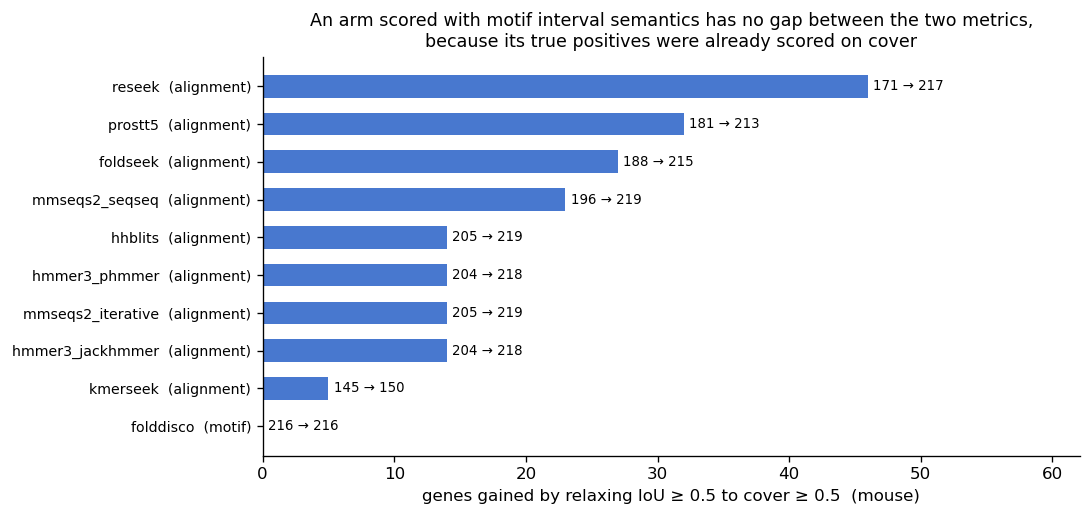

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

import mhc_region_utils as mu
import ortholog_analysis_utils as ou

FIG_DIR = Path("../figures")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight", "font.size": 10})

gene_map = mu.load_chr6_gene_map()
window = mu.load_mhc_window(gene_map)
core = gene_map.filter(pl.col("mhc_class").is_not_null())
gl = mu.load_gene_level()

WINDOW_ACC = window["accession"].to_list()
ALL_BASELINES = [t for t in mu.TOOL_LABELS if t != "kmerseek"]

# Which arms score an interval as an alignment, and which score it as a motif. Read from
# the pipeline's own metric table, filtered to the pfam truth set first: that file stacks
# three truth sets (pfam / pfamn / swissprot) and rows duplicate across them.
sem = (pl.read_parquet(mu.ALL_DOMAIN_METRICS,
                       columns=["truth_set", "tool", "interval_semantics"])
         .filter(pl.col("truth_set") == "pfam")
         .select("tool", "interval_semantics").unique())
SEMANTICS = dict(sem.iter_rows())

# folddisco reports motif intervals, so the pipeline scores its true positives on a
# cover-like rule while every other arm is scored on IoU. It is therefore not on the same
# axis as the rest and is held out of every head-to-head ranking below, and used instead as
# an independent control in section 3b.
BASELINES = [t for t in ALL_BASELINES if SEMANTICS.get(t) == "alignment"]
MOTIF_ARMS = [t for t in ALL_BASELINES if SEMANTICS.get(t) != "alignment"]

# Two definitions, carried side by side everywhere in this notebook.
#   delimited : >=1 call the run counted as a true positive (IoU >= 0.5 for an
#               alignment-semantics arm)
#   covered   : >=1 call overlapping at least half a true domain, whatever its boundaries
gl = gl.with_columns(
    delimited=pl.col("n_tp") > 0,
    covered=pl.col("best_cover").fill_null(0) >= 0.5,
    called=pl.col("n_calls") > 0,
    arm=pl.col("tool") + "." + pl.col("variant"),
)

audit = (gl.filter(pl.col("species") == "mouse")
           .group_by("tool")
           .agg(delimited=pl.col("query_acc").filter(pl.col("delimited")).n_unique(),
                covered=pl.col("query_acc").filter(pl.col("covered")).n_unique())
           .with_columns(gap=pl.col("covered") - pl.col("delimited"),
                         semantics=pl.col("tool").replace_strict(SEMANTICS, default="?"))
           .sort("gap", descending=True))
print(f"MHC-window query genes : {window.height}")
print(f"arms scored            : {gl['arm'].n_unique():_} "
      f"({gl.filter(pl.col('tool') == 'kmerseek')['variant'].n_unique():_} kmerseek)")
print(f"alignment-semantics baselines: {len(BASELINES)}   motif-semantics: {MOTIF_ARMS}")
print("\nmouse, genes reached under each metric (kmerseek pooled over all arms):")
with pl.Config(tbl_width_chars=180, tbl_rows=20):
    print(audit)

fig, ax = plt.subplots(figsize=(9.2, 4.4))
o = audit.sort("gap")
y = np.arange(o.height)
colors = ["#D65F5F" if s == "motif" else "#4878CF" for s in o["semantics"]]
ax.barh(y, o["gap"], 0.6, color=colors)
for i, r in enumerate(o.iter_rows(named=True)):
    ax.text(r["gap"] + 0.4, i, f"{r['delimited']} → {r['covered']}", va="center", fontsize=8)
ax.set_yticks(y)
ax.set_yticklabels([f"{t}  ({s})" for t, s in zip(o["tool"], o["semantics"])], fontsize=8.5)
ax.set_xlabel("genes gained by relaxing IoU ≥ 0.5 to cover ≥ 0.5  (mouse)")
ax.set_title("An arm scored with motif interval semantics has no gap between the two metrics,\n"
             "because its true positives were already scored on cover", fontsize=10.5)
ax.set_xlim(0, max(o["gap"].max() * 1.35, 5))
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_metric_semantics_audit.png", dpi=200)

## 1. How many MHC-region genes survive to each species

Rows are only written where an arm made at least one call, so a gene absent from the table
detected nothing — the counts below fill those in as zero rather than dropping them.

Left panel is `delimited`, right panel is `covered`, and kmerseek is drawn on both. The grey
band is the reachability floor from notebook 220: past zebrafish, no target proteome contains
an MHC platform or C1-set domain at all, so whatever is still being detected out there is
class III and the extended regions, not MHC molecules.

MHC-window genes (of 221) DELIMITED, 8 alignment-semantics baselines:
shape: (8, 10)
┌───────────────────┬───────┬─────────┬───────────┬───┬──────┬───────┬─────────────┬───────┐
│ tool              ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---               ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ str               ┆ u32   ┆ u32     ┆ u32       ┆   ┆ u32  ┆ u32   ┆ u32         ┆ u32   │
╞═══════════════════╪═══════╪═════════╪═══════════╪═══╪══════╪═══════╪═════════════╪═══════╡
│ hhblits           ┆ 205   ┆ 175     ┆ 193       ┆ … ┆ 135  ┆ 97    ┆ 115         ┆ 29    │
│ mmseqs2_iterative ┆ 205   ┆ 161     ┆ 178       ┆ … ┆ 117  ┆ 77    ┆ 90          ┆ 24    │
│ hmmer3_phmmer     ┆ 204   ┆ 170     ┆ 189       ┆ … ┆ 116  ┆ 74    ┆ 98          ┆ 20    │
│ hmmer3_jackhmmer  ┆ 204   ┆ 176     ┆ 192       ┆ … ┆ 122  ┆ 83    ┆ 96          ┆ 23    │
│ mmseqs2_seqseq    ┆ 196   ┆ 148     ┆ 161       ┆ … ┆ 110  ┆ 70    ┆ 87     

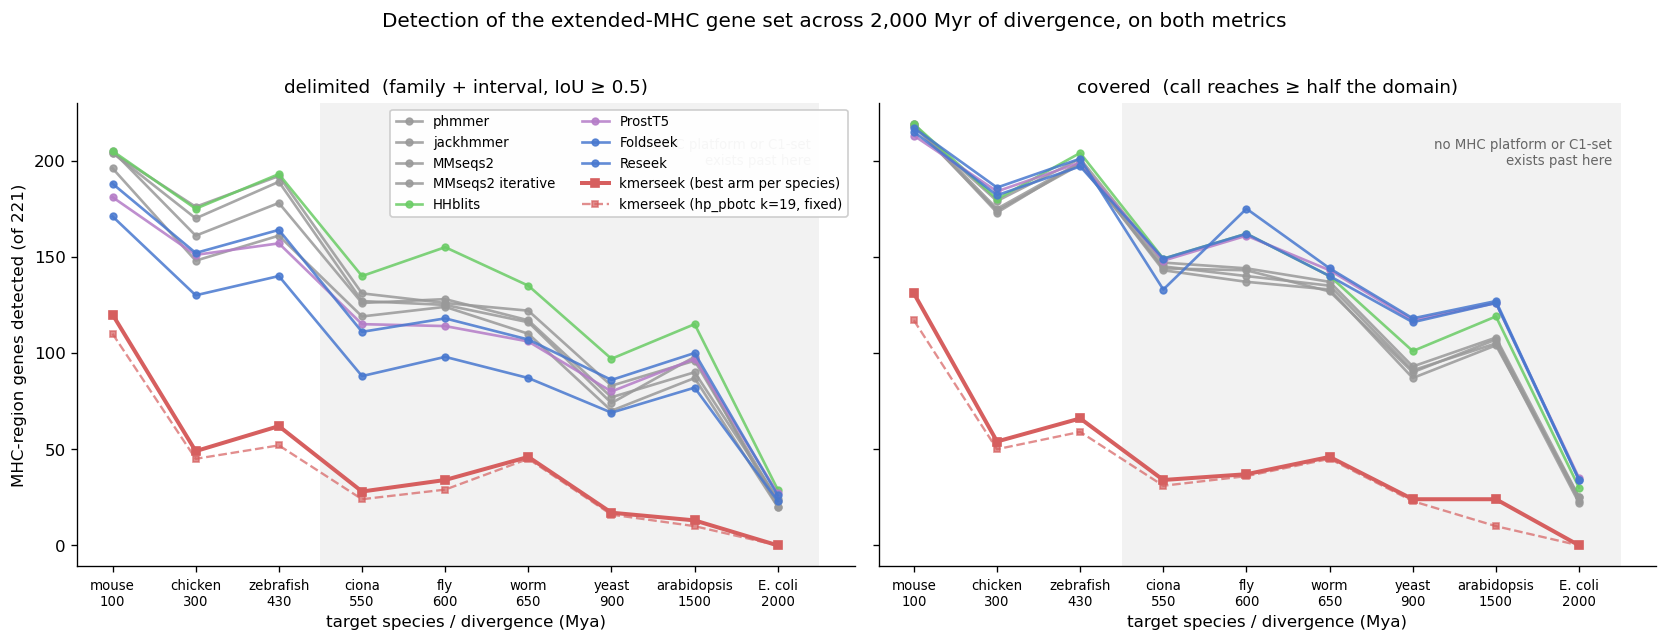

In [2]:
def detected_counts(frame, flag, tools=None):
    # Genes detected per (arm, species), zero-filled over the full grid: a gene an arm
    # never called on has no row at all, and must not be dropped from the denominator.
    f = frame if tools is None else frame.filter(pl.col("tool").is_in(tools))
    got = (f.filter(pl.col(flag))
             .group_by("arm", "tool", "species")
             .agg(pl.col("query_acc").n_unique().alias("n_detected")))
    grid = (f.select("arm", "tool").unique()
              .join(pl.DataFrame({"species": mu.SPECIES_ORDER}), how="cross"))
    return (grid.join(got, on=["arm", "tool", "species"], how="left")
                .with_columns(pl.col("n_detected").fill_null(0)))


base = detected_counts(gl, "delimited", BASELINES)
base_cov = detected_counts(gl, "covered", BASELINES)

# kmerseek: the sweep's best arm per species on each metric, plus one fixed arm carried
# across all species, because "best per species" is chosen using the number being plotted.
ks = detected_counts(gl, "delimited", ["kmerseek"])
ks_cov = detected_counts(gl, "covered", ["kmerseek"])
ks_best = ks.sort("n_detected", descending=True).group_by("species").head(1)
ks_cov_best = ks_cov.sort("n_detected", descending=True).group_by("species").head(1)
FIXED = "kmerseek.hp_pbotc_1st_ed2_k19_lcTrue"
ks_fixed = ks.filter(pl.col("arm") == FIXED)
ks_cov_fixed = ks_cov.filter(pl.col("arm") == FIXED)


def per_tool(frame):
    w = frame.select("tool", "species", "n_detected").pivot(
        on="species", index="tool", values="n_detected")
    return w.select(["tool"] + [s for s in mu.SPECIES_ORDER if s in w.columns])


print(f"MHC-window genes (of {window.height}) DELIMITED, {len(BASELINES)} alignment-semantics baselines:")
with pl.Config(tbl_width_chars=200, tbl_rows=20):
    print(per_tool(base).sort("mouse", descending=True))
print(f"\nMHC-window genes (of {window.height}) COVERED, same arms:")
with pl.Config(tbl_width_chars=200, tbl_rows=20):
    print(per_tool(base_cov).sort("mouse", descending=True))

rows = []
for sp in mu.SPECIES_ORDER:
    bd = base.filter(pl.col("species") == sp)["n_detected"]
    bc = base_cov.filter(pl.col("species") == sp)["n_detected"]
    kd = ks.filter(pl.col("species") == sp)["n_detected"].max()
    kc = ks_cov.filter(pl.col("species") == sp)["n_detected"].max()
    rows.append({"species": sp, "mya": mu.SPECIES_MYA[sp],
                 "base_delim_median": float(bd.median()), "ks_delim_best": int(kd),
                 "ratio_delim": round(kd / bd.median(), 3) if bd.median() else None,
                 "base_cov_median": float(bc.median()), "ks_cov_best": int(kc),
                 "ratio_cov": round(kc / bc.median(), 3) if bc.median() else None})
gap = pl.DataFrame(rows)
print("\nkmerseek best arm vs the baseline median, on both metrics:")
with pl.Config(tbl_width_chars=200, tbl_rows=12):
    print(gap)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
x = np.arange(len(mu.SPECIES_ORDER))
panels = [(axes[0], base, ks_best, ks_fixed, "delimited  (family + interval, IoU ≥ 0.5)"),
          (axes[1], base_cov, ks_cov_best, ks_cov_fixed, "covered  (call reaches ≥ half the domain)")]
for ax, frame, kb, kf, title in panels:
    for tool in BASELINES:
        sub = frame.filter(pl.col("tool") == tool)
        y = [sub.filter(pl.col("species") == s)["n_detected"].sum() for s in mu.SPECIES_ORDER]
        fam = mu.TOOL_FAMILY[tool]
        ax.plot(x, y, marker="o", ms=4, lw=1.6, color=mu.TOOL_FAMILY_COLORS[fam],
                alpha=0.85, label=mu.TOOL_LABELS[tool])
    y = [kb.filter(pl.col("species") == s)["n_detected"].sum() for s in mu.SPECIES_ORDER]
    ax.plot(x, y, marker="s", ms=5, lw=2.4, color=mu.TOOL_FAMILY_COLORS["kmerseek"],
            label="kmerseek (best arm per species)")
    yf = [kf.filter(pl.col("species") == s)["n_detected"].sum() for s in mu.SPECIES_ORDER]
    ax.plot(x, yf, marker="s", ms=4, lw=1.4, ls="--",
            color=mu.TOOL_FAMILY_COLORS["kmerseek"], alpha=0.7,
            label="kmerseek (hp_pbotc k=19, fixed)")
    ax.axvspan(2.5, len(x) - 0.5, color="#000000", alpha=0.05, lw=0)
    ax.text(len(x) - 0.6, window.height * 0.96, "no MHC platform or C1-set\nexists past here",
            ha="right", va="top", fontsize=8, color="#666666")
    ax.set_xticks(x)
    ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("target species / divergence (Mya)")
    for s_ in ("right", "top"):
        ax.spines[s_].set_visible(False)

axes[0].set_ylabel(f"MHC-region genes detected (of {window.height})")
axes[0].legend(fontsize=8, loc="upper right", ncol=2, framealpha=0.95)
fig.suptitle("Detection of the extended-MHC gene set across 2,000 Myr of divergence, "
             "on both metrics", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_mhc_detection_by_species.png", dpi=200)

## 1b. Where kmerseek's shortfall actually is

Three nested sets per arm, on the same 221 genes in mouse: genes the arm made **any** call
on, genes where some call **covered** at least half a true domain, and genes where some call
**delimited** one.

For an alignment-semantics baseline, nearly every gene is called on and nearly every gene is
covered; the losses happen at the IoU step, which is the step 223 shows is a property of the
target database. For kmerseek the losses happen one step earlier. Its best-delimiting arm
calls on 213 of 221 genes and covers half a domain on 129 of them. Relaxing IoU to cover
moves it from 120 to 129 — nine genes out of a ninety-three-gene shortfall.

The gap therefore **persists**. The baseline median in mouse is 200 genes delimited and 218
covered; kmerseek's best arm is 120 and 131. The ratio is 0.60 on both metrics, unchanged to
two decimal places. 223's mechanism is real, it is established independently on a different
question, and it does not explain this. Whatever kmerseek is missing here it is missing
before the boundary is scored.

mouse, nested per arm: any call → covered ≥ half a domain → delimited at IoU ≥ 0.5
shape: (12, 6)
┌───────────────────────────────────────────┬────────┬─────────┬───────────┬────────────────┬───────────────────────┐
│ arm                                       ┆ called ┆ covered ┆ delimited ┆ cover_recovers ┆ shortfall_from_called │
│ ---                                       ┆ ---    ┆ ---     ┆ ---       ┆ ---            ┆ ---                   │
│ str                                       ┆ u32    ┆ u32     ┆ u32       ┆ u32            ┆ u32                   │
╞═══════════════════════════════════════════╪════════╪═════════╪═══════════╪════════════════╪═══════════════════════╡
│ mmseqs2_iterative.s7                      ┆ 220    ┆ 219     ┆ 205       ┆ 14             ┆ 15                    │
│ hhblits.single_seq                        ┆ 221    ┆ 219     ┆ 205       ┆ 14             ┆ 16                    │
│ hmmer3_phmmer.default                     ┆ 219    ┆ 218     ┆ 204       ┆

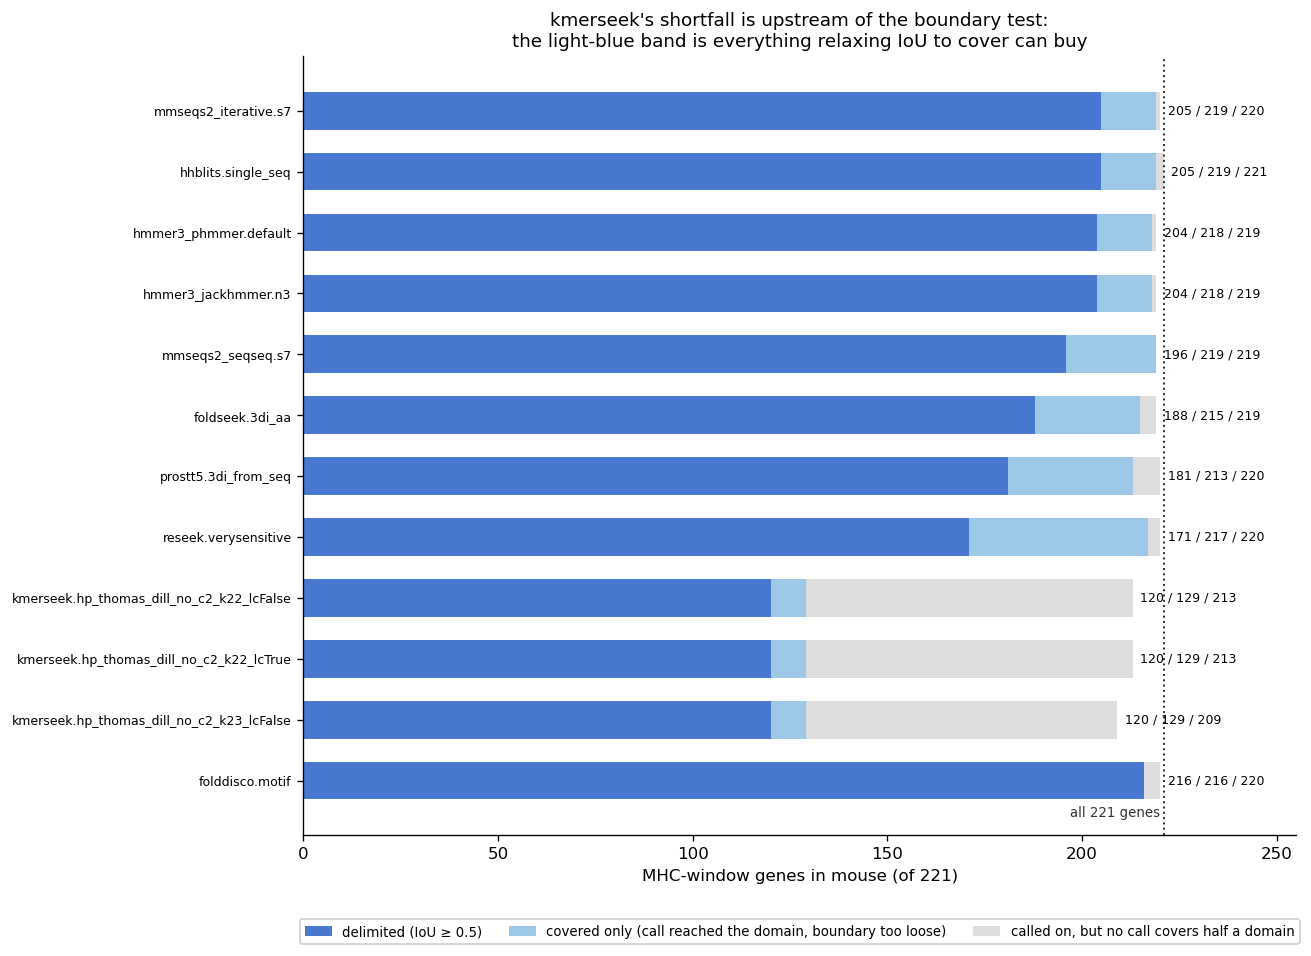

In [3]:
def nested_counts(species):
    g = gl.filter(pl.col("species") == species)
    return (g.group_by("tool", "arm")
             .agg(called=pl.col("query_acc").filter(pl.col("called")).n_unique(),
                  covered=pl.col("query_acc").filter(pl.col("covered")).n_unique(),
                  delimited=pl.col("query_acc").filter(pl.col("delimited")).n_unique()))


nest = nested_counts("mouse")
nb = nest.filter(pl.col("tool").is_in(BASELINES)).sort("delimited", descending=True)
# Deterministic tie-break: many kmerseek arms reach the same `delimited` count, and a plain
# sort on one column returns a different one of them on every run.
nk = (nest.filter(pl.col("tool") == "kmerseek")
          .sort(["delimited", "covered", "called", "arm"],
                descending=[True, True, True, False]).head(3))
nm = nest.filter(pl.col("tool").is_in(MOTIF_ARMS))
show = pl.concat([nb.select("arm", "called", "covered", "delimited"),
                  nk.select("arm", "called", "covered", "delimited"),
                  nm.select("arm", "called", "covered", "delimited")])
show = show.with_columns(
    cover_recovers=pl.col("covered") - pl.col("delimited"),
    shortfall_from_called=pl.col("called") - pl.col("delimited"))
print("mouse, nested per arm: any call → covered ≥ half a domain → delimited at IoU ≥ 0.5")
with pl.Config(tbl_width_chars=200, tbl_rows=20, fmt_str_lengths=42):
    print(show)

bd = base.filter(pl.col("species") == "mouse")["n_detected"]
bc = base_cov.filter(pl.col("species") == "mouse")["n_detected"]
kd = int(ks.filter(pl.col("species") == "mouse")["n_detected"].max())
kc = int(ks_cov.filter(pl.col("species") == "mouse")["n_detected"].max())
print(f"\nmouse baseline median  delimited {bd.median():.0f}   covered {bc.median():.0f}")
print(f"mouse kmerseek best    delimited {kd}   covered {kc}")
print(f"ratio kmerseek/baseline  delimited {kd / bd.median():.2f}   covered {kc / bc.median():.2f}")
best_arm = nk["arm"][0]
r0 = nest.filter(pl.col("arm") == best_arm).to_dicts()[0]
print(f"best kmerseek arm {best_arm}: called {r0['called']}, covered {r0['covered']}, "
      f"delimited {r0['delimited']} of {window.height}")
print(f"  relaxing IoU to cover recovers {r0['covered'] - r0['delimited']} genes of the "
      f"{r0['called'] - r0['delimited']}-gene shortfall against the genes it called on; "
      f"{r0['called'] - r0['covered']} are lost before the boundary is scored")

labels = show["arm"].to_list()
y = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(11, 0.42 * len(labels) + 3.0))
ax.barh(y, show["delimited"], 0.62, color="#4878CF", label="delimited (IoU ≥ 0.5)")
ax.barh(y, show["cover_recovers"], 0.62, left=show["delimited"], color="#9EC8E8",
        label="covered only (call reached the domain, boundary too loose)")
ax.barh(y, show["called"] - show["covered"], 0.62, left=show["covered"], color="#dddddd",
        label="called on, but no call covers half a domain")
ax.axvline(window.height, color="#333333", lw=1.2, ls=":")
ax.text(window.height - 1, len(labels) - 0.4, f"all {window.height} genes", ha="right",
        fontsize=8, color="#333333")
for i, r in enumerate(show.iter_rows(named=True)):
    ax.text(r["called"] + 2, i, f"{r['delimited']} / {r['covered']} / {r['called']}",
            va="center", fontsize=7.5)
ax.set_yticks(y)
ax.set_yticklabels(labels, fontsize=7.5)
ax.invert_yaxis()
ax.set_xlim(0, window.height + 34)
ax.set_xlabel(f"MHC-window genes in mouse (of {window.height})")
ax.set_title("kmerseek's shortfall is upstream of the boundary test:\n"
             "the light-blue band is everything relaxing IoU to cover can buy", fontsize=11)
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=3,
          framealpha=0.95)
for s_ in ("right", "top"):
    ax.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_shortfall_decomposition.png", dpi=200)

## 2. The cliff is real, but only the MHC genes themselves show it

Four panels of the same counts, one metric per column, and the difference between the rows is
the point.

**Top**, the 21 MHC molecules grouped by class. Every class is reached in every one of
mouse, chicken and zebrafish by every alignment-semantics baseline, on both metrics, and the
median past zebrafish is zero on both. The edge falls exactly on the jawed-vertebrate
boundary, which is where class I and class II were invented. TAP1/TAP2/TAPBP are the control
and behave the other way, holding up to *E. coli*.

The per-family target counts printed below are why. Past zebrafish no target proteome carries
a class I or class II platform at all, and ciona, worm, yeast, *Arabidopsis* and *E. coli*
carry no C1-set Ig either. Fly is the single exception: it carries exactly one PF07654
protein, and that one protein is why a minority of the baselines still reach the Ig half of
most MHC genes at 600 Mya while none of them reach anything in ciona at 550. That is
reachability doing the work, not a tool difference, and it is the reason a raw recall number
over these species is meaningless without the denominator.

**Bottom**, the same tools over the five xMHC sub-regions. The cliff is gone on both metrics.
All five sub-regions decay smoothly and almost identically, class III no faster or slower
than class I. That is not a contradiction — it is a reminder that the extended MHC is mostly
not MHC genes. 21 of the 221 proteins in the window are MHC molecules; the rest are
butyrophilins, TRIMs, zinc fingers, histones, olfactory receptors, complement and heat-shock
genes, and they behave like ordinary chr6.

So a claim about "the MHC region" and a claim about "MHC genes" are different claims, and
the second one is not obtainable by averaging over the first. Switching metric does not
change that, which is the check worth doing before believing it.

[delimited] median fraction of each MHC class (n=24 curated genes):
shape: (6, 10)
┌───────────────────┬───────┬─────────┬───────────┬───┬──────┬───────┬─────────────┬───────┐
│ grp               ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---               ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ str               ┆ f64   ┆ f64     ┆ f64       ┆   ┆ f64  ┆ f64   ┆ f64         ┆ f64   │
╞═══════════════════╪═══════╪═════════╪═══════════╪═══╪══════╪═══════╪═════════════╪═══════╡
│ I classical       ┆ 1.0   ┆ 1.0     ┆ 1.0       ┆ … ┆ 0.0  ┆ 0.0   ┆ 0.0         ┆ 0.0   │
│ I non-classical   ┆ 1.0   ┆ 1.0     ┆ 1.0       ┆ … ┆ 0.0  ┆ 0.0   ┆ 0.0         ┆ 0.0   │
│ processing (ctrl) ┆ 1.0   ┆ 1.0     ┆ 1.0       ┆ … ┆ 0.67 ┆ 0.67  ┆ 0.67        ┆ 0.67  │
│ II beta           ┆ 1.0   ┆ 1.0     ┆ 1.0       ┆ … ┆ 0.0  ┆ 0.0   ┆ 0.0         ┆ 0.0   │
│ II alpha          ┆ 1.0   ┆ 1.0     ┆ 1.0       ┆ … ┆ 0.0  ┆ 0.0   ┆ 0.0      

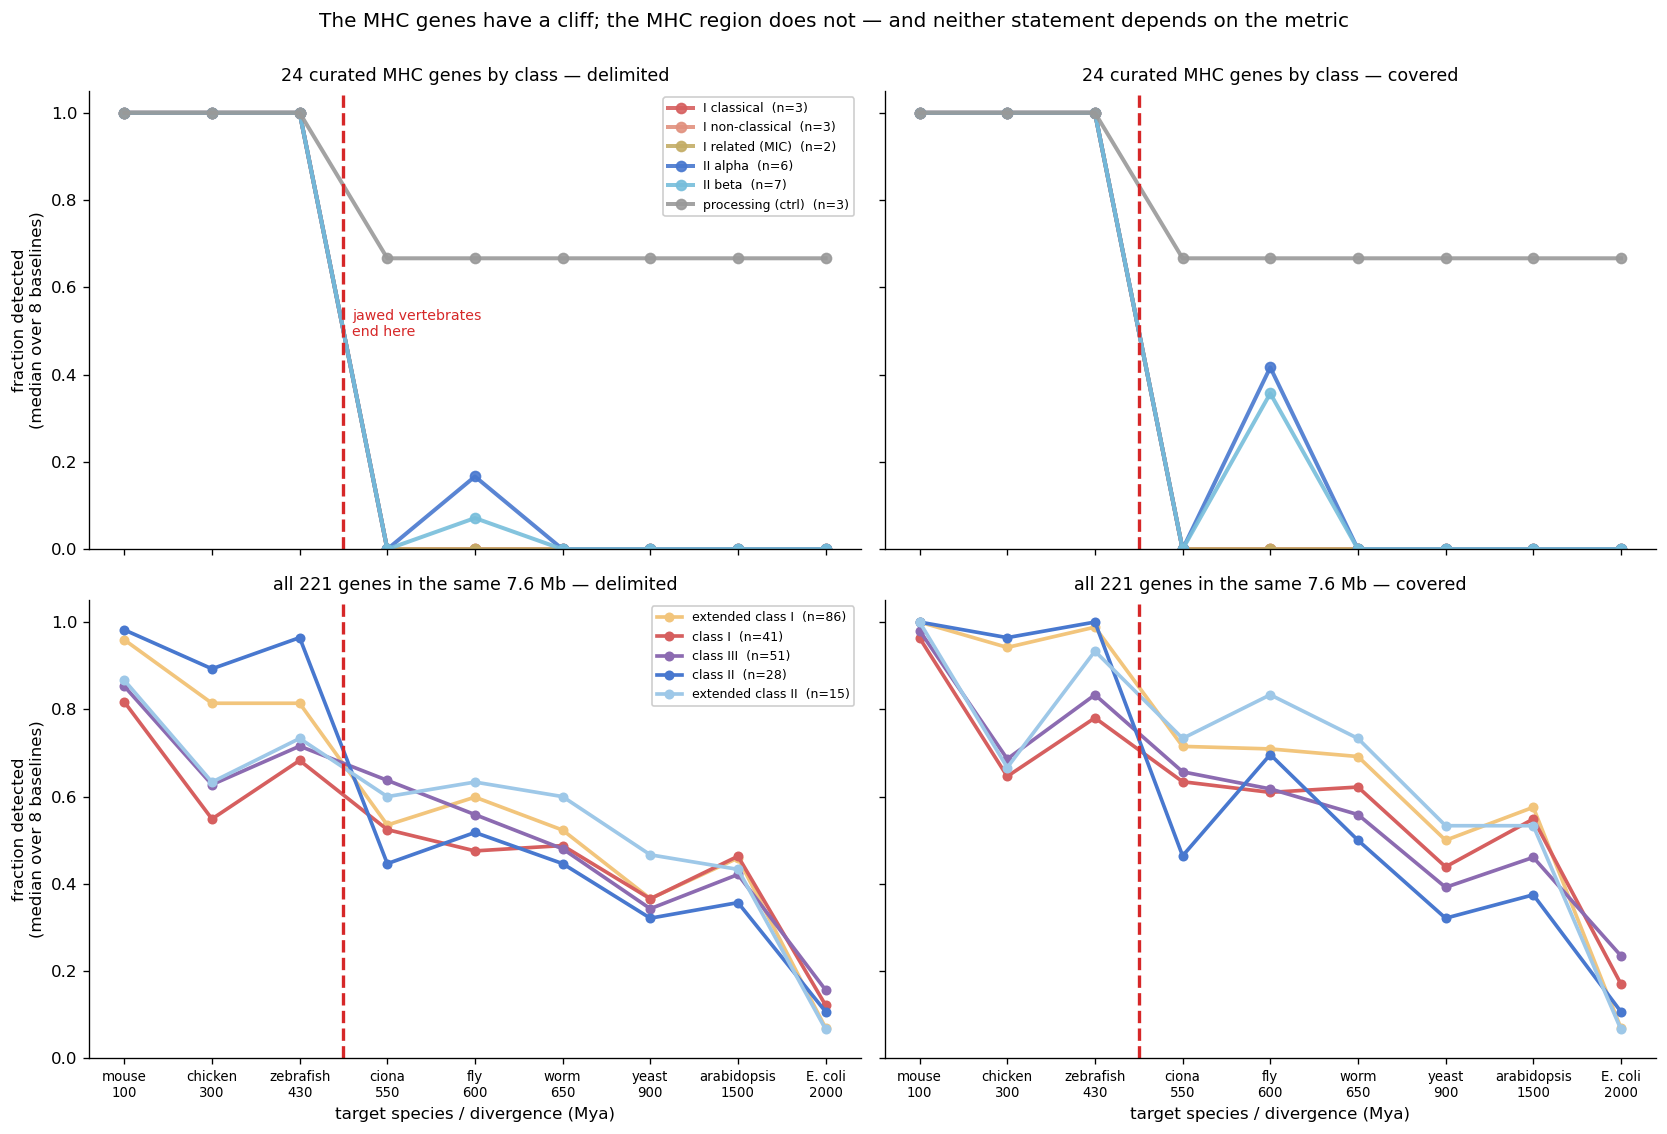

In [4]:
def median_fraction(label_col, sizes, labels, flag):
    # Median over the alignment-semantics baselines of the fraction of each group detected,
    # on the zero-filled grid so a group an arm never called on counts as 0, not as missing.
    tagged = (gl.filter(pl.col("tool").is_in(BASELINES))
                .join(label_col, on="query_acc", how="inner"))
    got = (tagged.filter(pl.col(flag))
                 .group_by("tool", "species", "grp")
                 .agg(pl.col("query_acc").n_unique().alias("n")))
    grid = (pl.DataFrame({"tool": BASELINES})
              .join(pl.DataFrame({"species": mu.SPECIES_ORDER}), how="cross")
              .join(pl.DataFrame({"grp": labels}), how="cross"))
    return (grid.join(got, on=["tool", "species", "grp"], how="left")
                .with_columns(pl.col("n").fill_null(0))
                .with_columns(total=pl.col("grp").replace_strict(sizes))
                .with_columns(frac=pl.col("n") / pl.col("total"))
                .group_by("grp", "species").agg(pl.col("frac").median().alias("frac")))


class_sizes = dict(core.group_by("mhc_class").len().iter_rows())
sub_sizes = dict(window.group_by("mhc_subregion").len().iter_rows())
CLASS_LBL = core.select(query_acc="accession", grp="mhc_class")
SUB_LBL = window.select(query_acc="accession", grp="mhc_subregion")

by_class = {f: median_fraction(CLASS_LBL, class_sizes, list(class_sizes), f)
            for f in ("delimited", "covered")}
by_sub = {f: median_fraction(SUB_LBL, sub_sizes, mu.MHC_SUBREGION_ORDER, f)
          for f in ("delimited", "covered")}


def show(frame, title):
    w = frame.pivot(on="species", index="grp", values="frac")
    w = w.select(["grp"] + [s for s in mu.SPECIES_ORDER if s in w.columns])
    print(title)
    with pl.Config(tbl_width_chars=200, tbl_rows=20):
        print(w.with_columns([pl.col(c).round(2) for c in w.columns if c != "grp"]))


for f in ("delimited", "covered"):
    show(by_class[f], f"[{f}] median fraction of each MHC class (n={core.height} curated genes):")
    show(by_sub[f], f"[{f}] median fraction of each xMHC sub-region (n={window.height} genes):")
    print()

MHC_FAMS = (list(mu.PFAM_PLATFORM) + [mu.PFAM_IG_C1, mu.PFAM_CLASS_I_TAIL]
            + list(mu.PFAM_TAP))
reach = (mu.target_family_counts(MHC_FAMS)
           .pivot(on="species", index="pfam_id", values="n_target_proteins")
           .with_columns(role=mu.domain_role(pl.col("pfam_id"))))
reach = reach.select(["pfam_id", "role"] + [s for s in mu.SPECIES_ORDER if s in reach.columns])
print("Target proteins carrying each MHC family — the reachability denominator:")
with pl.Config(tbl_rows=12, tbl_width_chars=190):
    print(reach)

fig, axes = plt.subplots(2, 2, figsize=(14, 9.4), sharey=True, sharex=True)
x = np.arange(len(mu.SPECIES_ORDER))
for col, f in enumerate(("delimited", "covered")):
    ax = axes[0, col]
    for grp in mu.MHC_CLASS_ORDER:
        s = by_class[f].filter(pl.col("grp") == grp)
        if s.height == 0:
            continue
        ax.plot(x, [s.filter(pl.col("species") == sp)["frac"].sum() for sp in mu.SPECIES_ORDER],
                marker="o", ms=6, lw=2.4, color=mu.MHC_CLASS_COLORS[grp], alpha=0.9,
                label=f"{grp}  (n={class_sizes[grp]})")
    ax.set_title(f"{core.height} curated MHC genes by class — {f}", fontsize=10.5)

    ax = axes[1, col]
    for grp in mu.MHC_SUBREGION_ORDER:
        s = by_sub[f].filter(pl.col("grp") == grp)
        ax.plot(x, [s.filter(pl.col("species") == sp)["frac"].sum() for sp in mu.SPECIES_ORDER],
                marker="o", ms=5, lw=2.2, color=mu.MHC_SUBREGION_COLORS[grp],
                label=f"{grp}  (n={sub_sizes[grp]})")
    ax.set_title(f"all {window.height} genes in the same 7.6 Mb — {f}", fontsize=10.5)

for ax in axes.ravel():
    ax.axvline(2.5, color="#D62728", lw=2, ls="--")
    ax.set_xticks(x)
    ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
    ax.set_ylim(0, 1.05)
    for sp_ in ("right", "top"):
        ax.spines[sp_].set_visible(False)
axes[0, 0].text(2.6, 0.55, "jawed vertebrates\nend here", fontsize=8.5, color="#D62728",
                va="top")
axes[0, 0].set_ylabel(f"fraction detected\n(median over {len(BASELINES)} baselines)")
axes[1, 0].set_ylabel(f"fraction detected\n(median over {len(BASELINES)} baselines)")
axes[0, 0].legend(fontsize=7.5, framealpha=0.95)
axes[1, 0].legend(fontsize=7.5, framealpha=0.95)
for ax in axes[1]:
    ax.set_xlabel("target species / divergence (Mya)")
fig.suptitle("The MHC genes have a cliff; the MHC region does not — and neither statement "
             "depends on the metric", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_mhc_detection_by_subregion.png", dpi=200)

## 3. The 24 curated MHC genes, one at a time

The sub-region fractions average over genes that are not comparable. This is the same
question asked gene by gene: across the alignment-semantics baselines, how many detect each
gene in each species, under each metric?

TAP1, TAP2 and TAPBP are the control row. TAP1/TAP2 are ABC transporters and should hold up
all the way to *E. coli*; if they do not, the failure is the pipeline, not the phylogeny.

Inside mouse, chicken and zebrafish the two heatmaps are nearly identical, and that is worth
stating rather than glossing. This is a **gene**-level flag: it fires if any domain on the
gene is recovered. Every class II gene carries a conserved C1-set Ig domain alongside its
platform, and the Ig domain clears IoU on its own, so the gene counts as delimited even
though 223 §1 shows its platform never does. The 223 mechanism is a domain-level effect and
is not visible at this resolution — §3b below is where it shows up.

Where the two heatmaps do differ is mostly out past the gnathostomes and on TAP1: 12 of the
216 cells change inside mouse/chicken/zebrafish and 24 change past zebrafish.

Number of the 8 alignment-semantics baselines [delimited] per gene:
shape: (24, 10)
┌─────────────┬───────┬─────────┬───────────┬───┬──────┬───────┬─────────────┬───────┐
│ hgnc_symbol ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ worm ┆ yeast ┆ arabidopsis ┆ ecoli │
│ ---         ┆ ---   ┆ ---     ┆ ---       ┆   ┆ ---  ┆ ---   ┆ ---         ┆ ---   │
│ str         ┆ u32   ┆ u32     ┆ u32       ┆   ┆ u32  ┆ u32   ┆ u32         ┆ u32   │
╞═════════════╪═══════╪═════════╪═══════════╪═══╪══════╪═══════╪═════════════╪═══════╡
│ HLA-A       ┆ 8     ┆ 8       ┆ 8         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
│ HLA-B       ┆ 8     ┆ 8       ┆ 8         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
│ HLA-C       ┆ 8     ┆ 8       ┆ 8         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
│ HLA-E       ┆ 8     ┆ 8       ┆ 8         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
│ HLA-F       ┆ 8     ┆ 8       ┆ 8         ┆ … ┆ 0    ┆ 0     ┆ 0           ┆ 0     │
│ HLA-G       ┆ 8     ┆ 8       ┆ 8         ┆ 

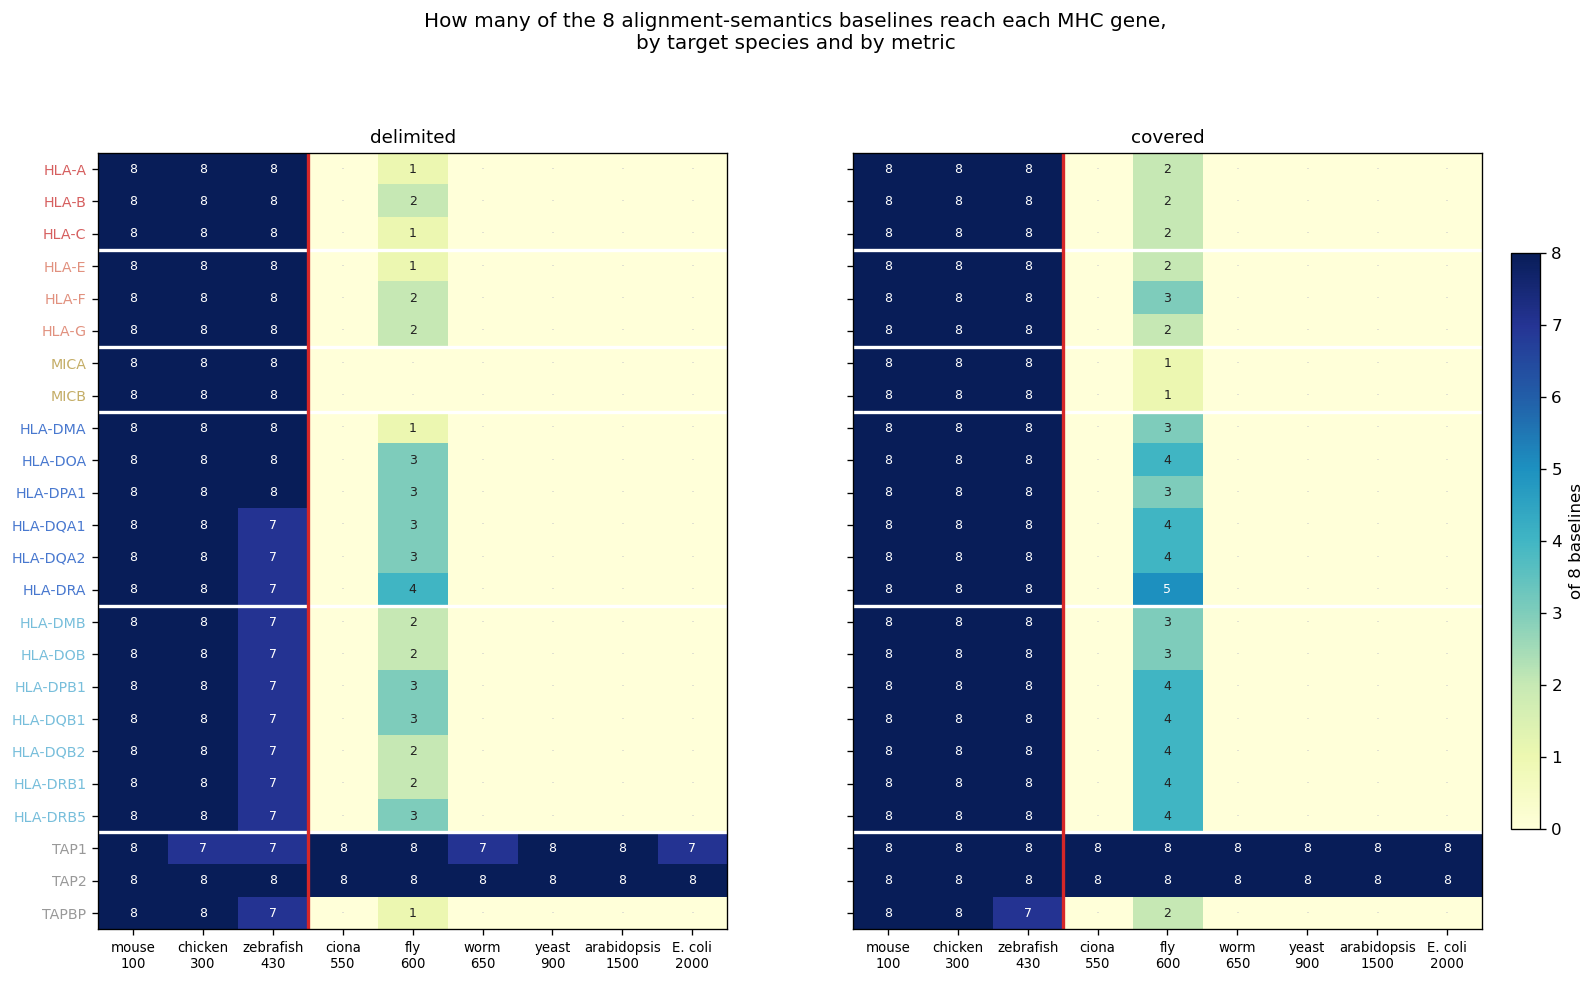

In [5]:
core_acc = core.select("accession", "hgnc_symbol", "mhc_class").rename({"accession": "query_acc"})
gcore = (gl.filter(pl.col("tool").is_in(BASELINES))
           .join(core_acc, on="query_acc", how="inner"))
order = (core_acc.with_columns(pl.col("mhc_class").replace_strict(
             {c: i for i, c in enumerate(mu.MHC_CLASS_ORDER)}, default=99).alias("k"))
         .sort("k", "hgnc_symbol"))
genes = order["hgnc_symbol"].to_list()
klass = dict(zip(order["hgnc_symbol"], order["mhc_class"]))


def gene_matrix(flag):
    hits = (gcore.filter(pl.col(flag))
                 .group_by("hgnc_symbol", "species")
                 .agg(pl.col("tool").n_unique().alias("n_tools")))
    grid = (pl.DataFrame({"hgnc_symbol": genes})
              .join(pl.DataFrame({"species": mu.SPECIES_ORDER}), how="cross")
              .join(hits, on=["hgnc_symbol", "species"], how="left")
              .with_columns(pl.col("n_tools").fill_null(0)))
    m = (grid.pivot(on="species", index="hgnc_symbol", values="n_tools")
             .select(["hgnc_symbol"] + mu.SPECIES_ORDER))
    return (m.join(pl.DataFrame({"hgnc_symbol": genes}).with_row_index("o"),
                   on="hgnc_symbol").sort("o").drop("o"))


mats = {f: gene_matrix(f) for f in ("delimited", "covered")}
for f in ("delimited", "covered"):
    print(f"Number of the {len(BASELINES)} alignment-semantics baselines [{f}] per gene:")
    with pl.Config(tbl_rows=30, tbl_width_chars=170):
        print(mats[f])
    print()

diff = (mats["covered"].select(mu.SPECIES_ORDER).to_numpy()
        - mats["delimited"].select(mu.SPECIES_ORDER).to_numpy())
gained = (pl.DataFrame({"hgnc_symbol": genes, "mhc_class": [klass[g] for g in genes]})
            .with_columns([pl.Series(s, diff[:, j].tolist())
                           for j, s in enumerate(mu.SPECIES_ORDER)])
            .with_columns(total=pl.sum_horizontal(mu.SPECIES_ORDER))
            .sort("total", descending=True))
print("Baseline tools gained by switching `delimited` -> `covered`, per gene and species:")
with pl.Config(tbl_rows=30, tbl_width_chars=190):
    print(gained.filter(pl.col("total") > 0))
print(f"genes where the two metrics are identical in every species: "
      f"{gained.filter(pl.col('total') == 0).height} of {len(genes)}")
print(f"total cells changed, gnathostomes only: {int(diff[:, :3].sum())}; "
      f"past zebrafish: {int(diff[:, 3:].sum())}")

fig, axes = plt.subplots(1, 2, figsize=(15.5, 8.4), sharey=True)
for ax, f in zip(axes, ("delimited", "covered")):
    arr = mats[f].select(mu.SPECIES_ORDER).to_numpy().astype(float)
    im = ax.imshow(arr, cmap="YlGnBu", vmin=0, vmax=len(BASELINES), aspect="auto")
    ax.set_xticks(range(len(mu.SPECIES_ORDER)))
    ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = int(arr[i, j])
            ax.text(j, i, "·" if v == 0 else str(v), ha="center", va="center", fontsize=7.5,
                    color="#cccccc" if v == 0 else ("white" if v > 4 else "#222222"))
    prev, bounds = None, []
    for i, g in enumerate(genes):
        if klass[g] != prev:
            bounds.append(i)
            prev = klass[g]
    for b in bounds[1:]:
        ax.axhline(b - 0.5, color="white", lw=2)
    ax.axvline(2.5, color="#D62728", lw=2)
    ax.set_title(f"{f}", fontsize=11)
axes[0].set_yticks(range(len(genes)))
axes[0].set_yticklabels(genes, fontsize=8.5)
for t, g in zip(axes[0].get_yticklabels(), genes):
    t.set_color(mu.MHC_CLASS_COLORS.get(klass[g], "#333333"))
fig.colorbar(im, ax=axes, label=f"of {len(BASELINES)} baselines", fraction=0.02, pad=0.02)
fig.suptitle(f"How many of the {len(BASELINES)} alignment-semantics baselines reach each MHC gene,\n"
             "by target species and by metric", y=1.02)
fig.savefig(FIG_DIR / "221_mhc_core_gene_heatmap.png", dpi=200)

## 3b. Folddisco: the same domains, two scoring rules, opposite answers

Everything above is our own code applied to our own tables, which is exactly the situation
in which a metric artefact is hardest to see. This section is the outside check.

Folddisco is the one arm in the run whose intervals the pipeline scores with **motif**
semantics rather than IoU-based **alignment** semantics — read off `interval_semantics` in
the run's metric table, filtered to the pfam truth set. Nothing about it was configured by
us for this notebook, and it is not a tool we wrote.

On the 13 class II platform domains in mouse (six PF00993 α1, seven PF00969 β1), the eight
alignment-semantics baselines score a true positive on **1 of the 104** arm-by-domain cells
between them, a single MMseqs2 call. Every one of the eight covers **13 of 13**. Folddisco's
own true-positive flag fires on **13 of 13** while its best IoU on those same domains is
**0 of 13** above 0.5.

The same domains, in the same proteins, against the same target proteome, scored as complete
misses under one interval rule and complete recoveries under the other. Its gene-level
`delimited` count equals its `covered` count exactly in all nine species, which is what a
cover-scored true positive looks like from the outside. That is why folddisco is held out of
every ranking table in this notebook: it is not on the same axis as the rest.

Class II platform domains (PF00993 α1 + PF00969 β1), per arm:
shape: (27, 7)
┌───────────┬───────────────────┬───────────┬─────┬────────┬─────────────┬───────────────┐
│ species   ┆ tool              ┆ semantics ┆ n   ┆ run_tp ┆ iou_ge_half ┆ cover_ge_half │
│ ---       ┆ ---               ┆ ---       ┆ --- ┆ ---    ┆ ---         ┆ ---           │
│ str       ┆ str               ┆ str       ┆ i64 ┆ i64    ┆ i64         ┆ i64           │
╞═══════════╪═══════════════════╪═══════════╪═════╪════════╪═════════════╪═══════════════╡
│ chicken   ┆ foldseek          ┆ alignment ┆ 13  ┆ 0      ┆ 0           ┆ 13            │
│ chicken   ┆ hhblits           ┆ alignment ┆ 13  ┆ 0      ┆ 0           ┆ 13            │
│ chicken   ┆ hmmer3_jackhmmer  ┆ alignment ┆ 13  ┆ 0      ┆ 0           ┆ 13            │
│ chicken   ┆ hmmer3_phmmer     ┆ alignment ┆ 13  ┆ 0      ┆ 0           ┆ 12            │
│ chicken   ┆ mmseqs2_iterative ┆ alignment ┆ 13  ┆ 0      ┆ 0           ┆ 10            │
│ chicken   ┆

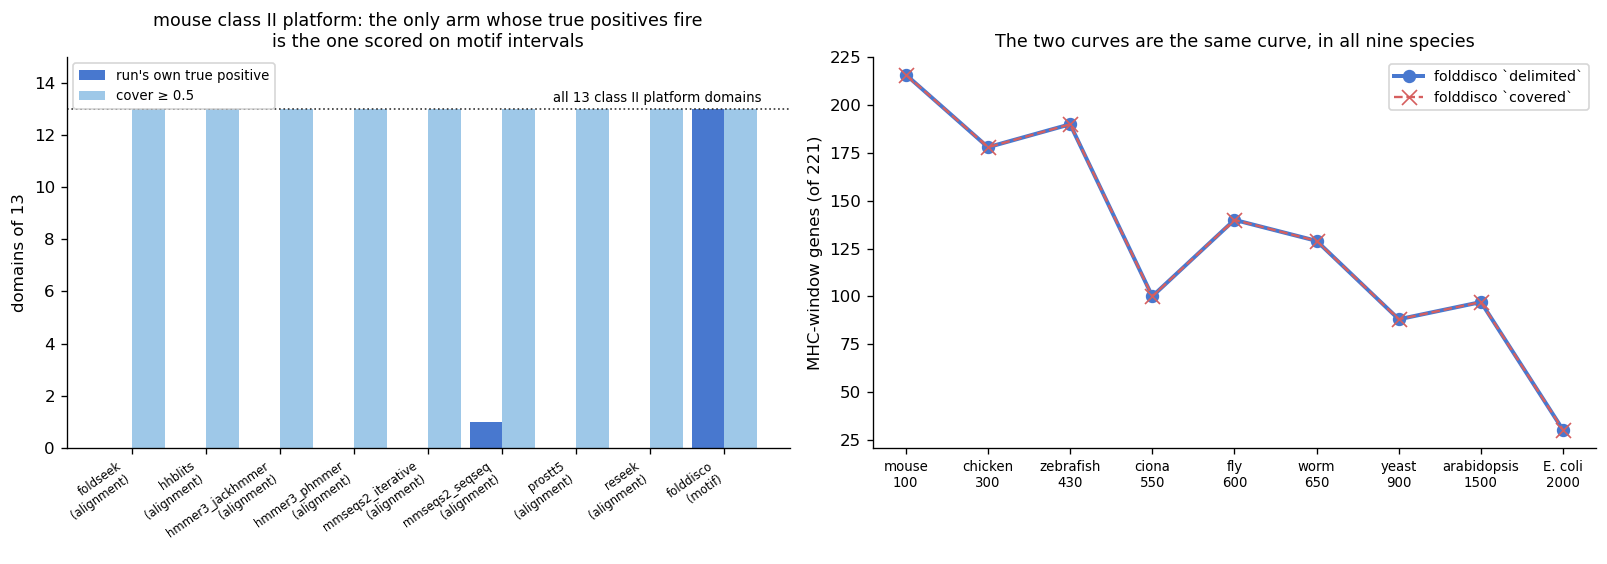

In [6]:
dlv = mu.load_domain_level()
ct = mu.core_truth()
truth_dom = ct.select("query_acc", "pfam_id", "role", "hgnc_symbol", "mhc_class").unique()
arms_dom = (dlv.filter(pl.col("tool").is_in(ALL_BASELINES))
               .select("tool", "variant").unique())
CLASS_II = ["PF00993", "PF00969"]

rows = []
for sp in mu.GNATHOSTOME_SPECIES:
    # zero-filled: a (domain, arm) pair with no call row must count as a miss
    grid = truth_dom.join(arms_dom, how="cross")
    got = (dlv.filter((pl.col("species") == sp) & pl.col("tool").is_in(ALL_BASELINES))
              .select("query_acc", "pfam_id", "tool", "variant", "found",
                      "best_iou", "best_cover"))
    g = (grid.join(got, on=["query_acc", "pfam_id", "tool", "variant"], how="left")
             .with_columns(found=pl.col("found").fill_null(False),
                           best_iou=pl.col("best_iou").fill_null(0.0),
                           best_cover=pl.col("best_cover").fill_null(0.0)))
    c2 = g.filter(pl.col("pfam_id").is_in(CLASS_II))
    for r in c2.group_by("tool").agg(n=pl.len(),
                                     run_tp=pl.col("found").sum(),
                                     iou_ge_half=(pl.col("best_iou") >= 0.5).sum(),
                                     cover_ge_half=(pl.col("best_cover") >= 0.5).sum()
                                     ).iter_rows(named=True):
        r["species"] = sp
        r["semantics"] = SEMANTICS.get(r["tool"], "?")
        rows.append(r)
c2tab = pl.DataFrame(rows).select("species", "tool", "semantics", "n", "run_tp",
                                  "iou_ge_half", "cover_ge_half").sort("species", "semantics",
                                                                       "tool")
print("Class II platform domains (PF00993 α1 + PF00969 β1), per arm:")
with pl.Config(tbl_rows=40, tbl_width_chars=180):
    print(c2tab)

fd = (gl.filter(pl.col("tool").is_in(MOTIF_ARMS))
        .group_by("species")
        .agg(delimited=pl.col("query_acc").filter(pl.col("delimited")).n_unique(),
             covered=pl.col("query_acc").filter(pl.col("covered")).n_unique())
        .with_columns(identical=pl.col("delimited") == pl.col("covered"))
        .with_columns(mya=pl.col("species").replace_strict(mu.SPECIES_MYA)).sort("mya"))
print("\nfolddisco gene-level counts: its `delimited` is a cover number in every species")
with pl.Config(tbl_rows=12, tbl_width_chars=160):
    print(fd)

mouse_c2 = c2tab.filter(pl.col("species") == "mouse")
aln = mouse_c2.filter(pl.col("semantics") == "alignment")
mot = mouse_c2.filter(pl.col("semantics") == "motif")
print(f"\nmouse class II platforms, {aln.height} alignment-semantics arms: "
      f"run true positives {aln['run_tp'].sum()}/{aln['n'].sum()}, "
      f"cover ≥ 0.5 {aln['cover_ge_half'].sum()}/{aln['n'].sum()}")
print(f"mouse class II platforms, folddisco (motif): "
      f"run true positives {mot['run_tp'].sum()}/{mot['n'].sum()}, "
      f"IoU ≥ 0.5 {mot['iou_ge_half'].sum()}/{mot['n'].sum()}")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
ax = axes[0]
tools = mouse_c2["tool"].to_list()
xx = np.arange(len(tools))
ax.bar(xx - 0.22, mouse_c2["run_tp"], 0.44, color="#4878CF", label="run's own true positive")
ax.bar(xx + 0.22, mouse_c2["cover_ge_half"], 0.44, color="#9EC8E8", label="cover ≥ 0.5")
ax.set_xticks(xx)
ax.set_xticklabels([f"{t}\n({s})" for t, s in zip(tools, mouse_c2["semantics"])],
                   fontsize=7, rotation=35, ha="right")
ax.axhline(13, color="#333333", lw=1.0, ls=":")
ax.text(len(tools) - 0.5, 13.25, "all 13 class II platform domains", ha="right", fontsize=8)
ax.set_ylabel("domains of 13")
ax.set_ylim(0, 15)
ax.set_title("mouse class II platform: the only arm whose true positives fire\n"
             "is the one scored on motif intervals", fontsize=10.5)
ax.legend(fontsize=8)

ax = axes[1]
sp_order = [s for s in mu.SPECIES_ORDER]
xx = np.arange(len(sp_order))
d = [fd.filter(pl.col("species") == s)["delimited"].sum() for s in sp_order]
c = [fd.filter(pl.col("species") == s)["covered"].sum() for s in sp_order]
ax.plot(xx, d, marker="o", ms=7, lw=2.4, color="#4878CF", label="folddisco `delimited`")
ax.plot(xx, c, marker="x", ms=9, lw=1.4, ls="--", color="#D65F5F",
        label="folddisco `covered`")
ax.set_xticks(xx)
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in sp_order], fontsize=8)
ax.set_ylabel(f"MHC-window genes (of {window.height})")
ax.set_title("The two curves are the same curve, in all nine species", fontsize=10.5)
ax.legend(fontsize=8.5)
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_folddisco_metric_control.png", dpi=200)

## 4. kmerseek across the sweep

About 400 kmerseek arms were scored per species. The question the sweep answers is not "does
kmerseek beat phmmer here" — §1 and §1b already show it does not, on either metric — but
whether an alphabet family and k-size range exists where the MHC region behaves differently
from the rest, and how the HP alphabets compare with protein and Dayhoff on the same genes.

Both metrics are swept. If the alphabet ranking flipped between them, the ranking would be a
statement about boundary geometry rather than about the encoding. It does not flip.

[delimited] best arm per alphabet: MHC-window genes reached
shape: (19, 9)
┌──────────────────────────┬───────┬─────────┬───────────┬───┬─────┬──────┬───────┬─────────────┐
│ alphabet                 ┆ mouse ┆ chicken ┆ zebrafish ┆ … ┆ fly ┆ worm ┆ yeast ┆ arabidopsis │
│ ---                      ┆ ---   ┆ ---     ┆ ---       ┆   ┆ --- ┆ ---  ┆ ---   ┆ ---         │
│ str                      ┆ u32   ┆ u32     ┆ u32       ┆   ┆ u32 ┆ u32  ┆ u32   ┆ u32         │
╞══════════════════════════╪═══════╪═════════╪═══════════╪═══╪═════╪══════╪═══════╪═════════════╡
│ hp_thomas_dill_no_c2     ┆ 120   ┆ 47      ┆ 62        ┆ … ┆ 30  ┆ 43   ┆ 14    ┆ 13          │
│ hp_kyte_doolittle2       ┆ 119   ┆ 49      ┆ 52        ┆ … ┆ 32  ┆ 44   ┆ 13    ┆ 10          │
│ hp_thomas_dill2          ┆ 118   ┆ 47      ┆ 58        ┆ … ┆ 30  ┆ 46   ┆ 17    ┆ 11          │
│ hp_pbotc_1st_ed2         ┆ 112   ┆ 45      ┆ 52        ┆ … ┆ 29  ┆ 45   ┆ 17    ┆ 10          │
│ hp_lehninger2            ┆ 109   ┆ 43    

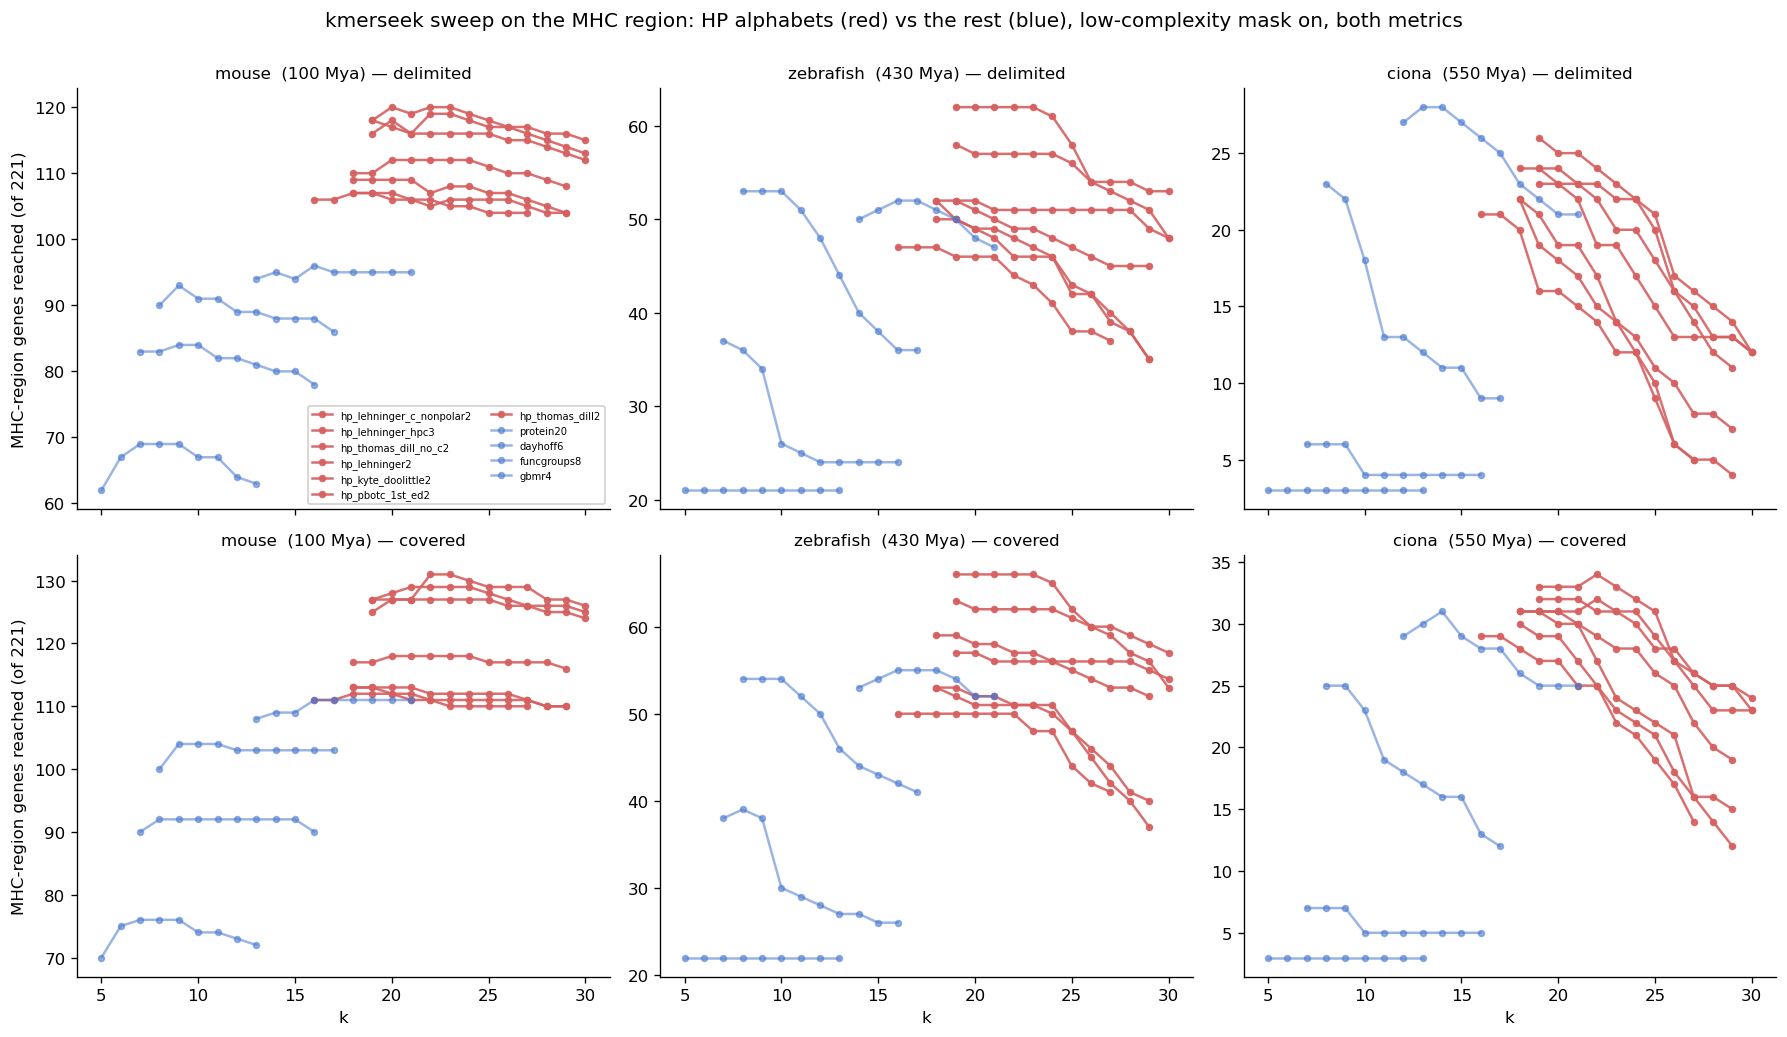

In [7]:
ksw = (gl.filter(pl.col("tool") == "kmerseek")
         .with_columns(
             alphabet=pl.col("variant").str.replace(r"_k\d+_lc(True|False)$", ""),
             ksize=pl.col("variant").str.extract(r"_k(\d+)_lc", 1).cast(pl.Int64),
             lc=pl.col("variant").str.ends_with("lcTrue")))


def sweep(flag):
    return (ksw.filter(pl.col(flag))
               .group_by("alphabet", "ksize", "lc", "species")
               .agg(pl.col("query_acc").n_unique().alias("n_detected")))


det = {f: sweep(f) for f in ("delimited", "covered")}
fam = {f: (det[f].group_by("alphabet", "species").agg(pl.col("n_detected").max().alias("best"))
               .pivot(on="species", index="alphabet", values="best"))
       for f in ("delimited", "covered")}
for f in ("delimited", "covered"):
    w = fam[f]
    cols = ["alphabet"] + [s for s in mu.SPECIES_ORDER if s in w.columns]
    print(f"[{f}] best arm per alphabet: MHC-window genes reached")
    with pl.Config(tbl_rows=30, tbl_width_chars=190):
        print(w.select(cols).sort("mouse", descending=True))
    print()

rank_d = fam["delimited"].select("alphabet", "mouse").sort("mouse", descending=True)
rank_c = fam["covered"].select("alphabet", "mouse").sort("mouse", descending=True)
cmp = (rank_d.with_row_index("rank_delim").rename({"mouse": "mouse_delim"})
       .join(rank_c.with_row_index("rank_cov").rename({"mouse": "mouse_cov"}),
             on="alphabet", how="inner")
       .with_columns(rank_shift=pl.col("rank_cov").cast(pl.Int64)
                     - pl.col("rank_delim").cast(pl.Int64))
       .sort("rank_delim"))
print("mouse alphabet ranking under the two metrics (rank_shift 0 = same position):")
with pl.Config(tbl_rows=30, tbl_width_chars=170):
    print(cmp)

ALL_ALPH = fam["delimited"]["alphabet"].to_list()
HP = [a for a in ALL_ALPH if a.startswith("hp_")]
SHOW = HP + [a for a in ["protein20", "dayhoff6", "funcgroups8", "gbmr4"] if a in ALL_ALPH]
fig, axes = plt.subplots(2, 3, figsize=(15, 8.6), sharex=True)
for row, f in enumerate(("delimited", "covered")):
    for col, sp in enumerate(["mouse", "zebrafish", "ciona"]):
        ax = axes[row, col]
        d = det[f].filter((pl.col("species") == sp) & pl.col("lc"))
        for a in SHOW:
            s = d.filter(pl.col("alphabet") == a).sort("ksize")
            if s.height == 0:
                continue
            ax.plot(s["ksize"], s["n_detected"], marker="o", ms=3.5, lw=1.5,
                    color="#D65F5F" if a.startswith("hp_") else "#4878CF",
                    alpha=0.9 if a.startswith("hp_") else 0.55,
                    label=a if (row == 0 and sp == "mouse") else None)
        ax.set_title(f"{sp}  ({mu.SPECIES_MYA[sp]} Mya) — {f}", fontsize=10)
        for s_ in ("right", "top"):
            ax.spines[s_].set_visible(False)
        if row == 1:
            ax.set_xlabel("k")
    axes[row, 0].set_ylabel(f"MHC-region genes reached (of {window.height})")
axes[0, 0].legend(fontsize=6.0, ncol=2, framealpha=0.9)
fig.suptitle("kmerseek sweep on the MHC region: HP alphabets (red) vs the rest (blue), "
             "low-complexity mask on, both metrics", y=1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_mhc_kmerseek_sweep.png", dpi=200)

## Summary

[delimited] mouse      baselines 171-205 of 221   kmerseek best 120
[delimited] zebrafish  baselines 140-193 of 221   kmerseek best  62
[delimited] ecoli      baselines  20- 29 of 221   kmerseek best   0
[covered  ] mouse      baselines 213-219 of 221   kmerseek best 131
[covered  ] zebrafish  baselines 197-204 of 221   kmerseek best  66
[covered  ] ecoli      baselines  22- 35 of 221   kmerseek best   0

Curated MHC genes (excluding the TAP controls) vs the TAP control, both metrics:
shape: (9, 6)
┌─────────────┬──────┬──────────────┬─────────┬──────────────┬─────────┐
│ species     ┆ mya  ┆ mhc_mean_del ┆ tap_del ┆ mhc_mean_cov ┆ tap_cov │
│ ---         ┆ ---  ┆ ---          ┆ ---     ┆ ---          ┆ ---     │
│ str         ┆ i64  ┆ f64          ┆ f64     ┆ f64          ┆ f64     │
╞═════════════╪══════╪══════════════╪═════════╪══════════════╪═════════╡
│ mouse       ┆ 100  ┆ 1.0          ┆ 1.0     ┆ 1.0          ┆ 1.0     │
│ chicken     ┆ 300  ┆ 1.0          ┆ 1.0     ┆ 1.0       

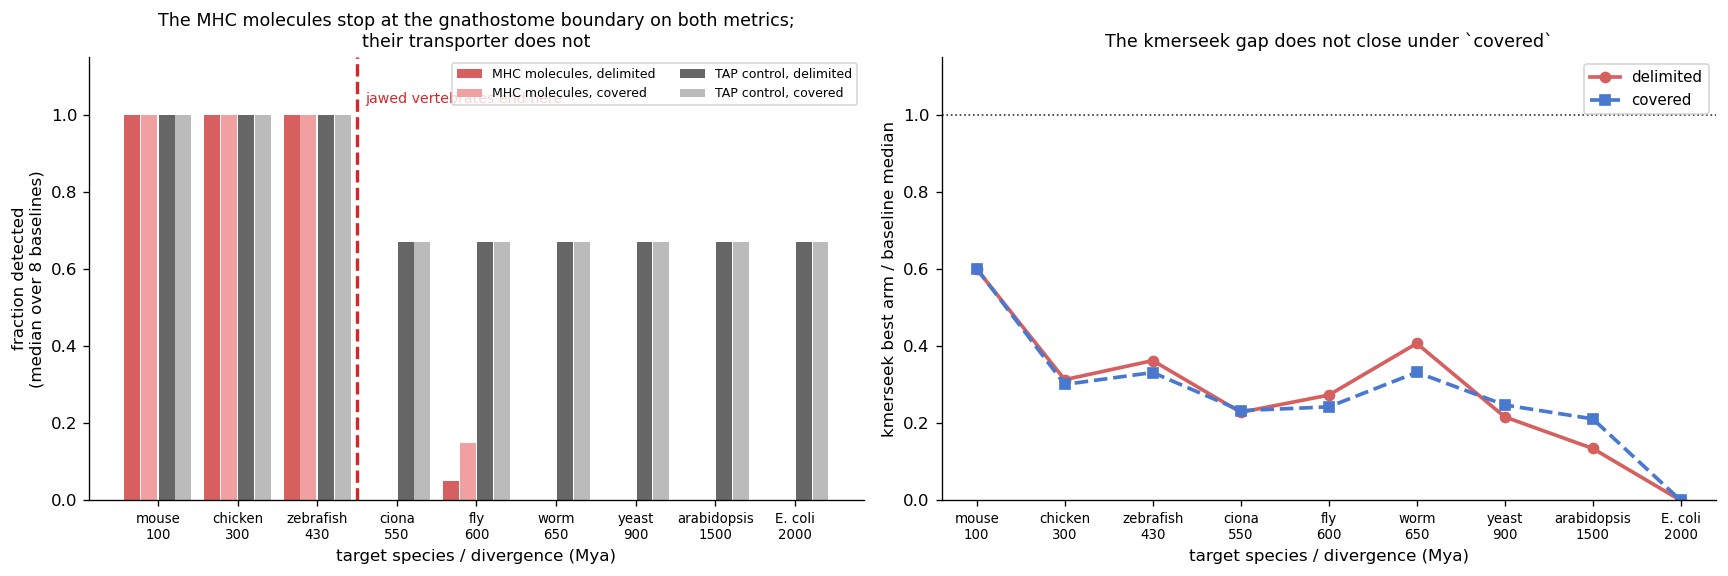

In [8]:
for f, frame, kframe in (("delimited", base, ks), ("covered", base_cov, ks_cov)):
    for sp in ("mouse", "zebrafish", "ecoli"):
        v = frame.filter(pl.col("species") == sp)["n_detected"]
        k = kframe.filter(pl.col("species") == sp)["n_detected"].max()
        print(f"[{f:9s}] {sp:10s} baselines {v.min():3d}-{v.max():3d} of {window.height}   "
              f"kmerseek best {k:3d}")

mhc_only = {f: by_class[f].filter(pl.col("grp") != "processing (ctrl)")
            for f in ("delimited", "covered")}
ctrl = {f: by_class[f].filter(pl.col("grp") == "processing (ctrl)")
        for f in ("delimited", "covered")}
rows = []
for sp in mu.SPECIES_ORDER:
    r = {"species": sp, "mya": mu.SPECIES_MYA[sp]}
    for f in ("delimited", "covered"):
        v = mhc_only[f].filter(pl.col("species") == sp)["frac"]
        r[f"mhc_mean_{f[:3]}"] = round(v.mean(), 2)
        r[f"tap_{f[:3]}"] = round(ctrl[f].filter(pl.col("species") == sp)["frac"].sum(), 2)
    rows.append(r)
final = pl.DataFrame(rows)
print("\nCurated MHC genes (excluding the TAP controls) vs the TAP control, both metrics:")
with pl.Config(tbl_rows=12, tbl_width_chars=180):
    print(final)

ks_by_sp = (ks.group_by("species").agg(pl.col("n_detected").max().alias("best"))
              .with_columns(mya=pl.col("species").replace_strict(mu.SPECIES_MYA))
              .sort("mya"))
print("\nkmerseek family-identity reach (best arm, delimited), by divergence:")
with pl.Config(tbl_rows=12, tbl_width_chars=140):
    print(ks_by_sp)

fig, axes = plt.subplots(1, 2, figsize=(14.5, 4.9))
x = np.arange(len(mu.SPECIES_ORDER))
ax = axes[0]
ax.bar(x - 0.32, final["mhc_mean_del"], 0.2, color="#D65F5F",
       label="MHC molecules, delimited")
ax.bar(x - 0.11, final["mhc_mean_cov"], 0.2, color="#F0A0A0",
       label="MHC molecules, covered")
ax.bar(x + 0.11, final["tap_del"], 0.2, color="#666666", label="TAP control, delimited")
ax.bar(x + 0.32, final["tap_cov"], 0.2, color="#bbbbbb", label="TAP control, covered")
ax.axvline(2.5, color="#D62728", lw=2, ls="--")
ax.text(2.6, 1.06, "jawed vertebrates end here", fontsize=8.5, color="#D62728", va="top")
ax.set_xticks(x)
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel(f"fraction detected\n(median over {len(BASELINES)} baselines)")
ax.set_ylim(0, 1.15)
ax.set_title("The MHC molecules stop at the gnathostome boundary on both metrics;\n"
             "their transporter does not", fontsize=10.5)
ax.legend(fontsize=7.5, ncol=2)

ax = axes[1]
bd_med = [base.filter(pl.col("species") == s)["n_detected"].median() for s in mu.SPECIES_ORDER]
bc_med = [base_cov.filter(pl.col("species") == s)["n_detected"].median() for s in mu.SPECIES_ORDER]
kd_b = [ks.filter(pl.col("species") == s)["n_detected"].max() for s in mu.SPECIES_ORDER]
kc_b = [ks_cov.filter(pl.col("species") == s)["n_detected"].max() for s in mu.SPECIES_ORDER]
ax.plot(x, [k / b if b else np.nan for k, b in zip(kd_b, bd_med)], marker="o", ms=6, lw=2.2,
        color="#D65F5F", label="delimited")
ax.plot(x, [k / b if b else np.nan for k, b in zip(kc_b, bc_med)], marker="s", ms=6, lw=2.2,
        ls="--", color="#4878CF", label="covered")
ax.axhline(1.0, color="#333333", lw=1.0, ls=":")
ax.set_xticks(x)
ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel("kmerseek best arm / baseline median")
ax.set_ylim(0, 1.15)
ax.set_title("The kmerseek gap does not close under `covered`", fontsize=10.5)
ax.legend(fontsize=9)
for a_ in axes:
    a_.set_xlabel("target species / divergence (Mya)")
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_mhc_vs_tap_control.png", dpi=200)

Four things come out of this.

**The MHC genes stop exactly where jawed vertebrates do.** All 21 MHC molecules are
reached in mouse, chicken and zebrafish by every alignment-semantics baseline, on both
metrics, and the median past zebrafish is zero on both. In ciona, worm, yeast, *Arabidopsis*
and *E. coli* not one baseline reaches any MHC molecule. Fly is the one place a minority of
them still do, and the reason is in the denominator rather than in the tools: fly's proteome
carries exactly one PF07654 protein, so the conserved Ig half of an MHC molecule has
something to match while the platform has nothing anywhere past zebrafish. TAP1/TAP2, ABC
transporters sitting in the middle of the class II region, keep being detected all the way to
*E. coli*. Same region, same search, and the edge lands on the gnathostome boundary rather
than anywhere a tool artefact would put it. The ciona zero is the run's own per-family count
from
`ciona_domain_map.parquet` and is not a coverage artefact: that map carries 20,234 domain
instances over 10,658 proteins, contains zero PF00129, PF00993, PF00969 and PF07654, and
still carries the TAP families (PF00664 and PF00005), which is what shows the map is not
truncated.

**That cliff is invisible if you average over the region.** The five xMHC sub-regions all
decay smoothly and almost identically, class III no differently from class I, under either
metric. Only 21 of the 221 proteins in the window are MHC molecules; the rest behave like
ordinary chr6. "The MHC region" and "MHC genes" are different claims and the second does not
come out of the first.

**The kmerseek gap persists under cover.** Notebook 223 shows that under IoU a domain is
delimitable only when its length fraction is at least 0.5 or the target proteome holds a
partner-free example of the family to inherit a tight boundary from — a property of the
database, not of the tool. Recomputing this notebook's headline on `covered`, which does not
have that property, moves kmerseek from 120 to 131 genes in mouse and moves the baseline
median from 200 to 218. The ratio is 0.60 either way. The earlier claim that the deficit was
boundary tightness rather than sensitivity was wrong: kmerseek's best-delimiting arm calls on
213 of 221 genes but covers half a domain on only 129, so 84 of its 93 missing genes are lost
before the boundary is scored at all. 223's mechanism is right about class II platforms and
does not carry the region-wide comparison.

**Folddisco is the control that shows the mechanism is not ours.** It is scored with motif
interval semantics, so its true positives are cover-scored, and it recovers all 13 mouse
class II platform domains where the eight IoU-scored arms recover none. Its gene-level
`delimited` count equals its `covered` count in all nine species. Same domains, two scoring
rules, opposite answers, from a tool we did not write and did not configure. That is why it
sits out of every ranking table above.

## 6. Are the genes detected at 2,000 Mya the conserved ones, or the HLA genes?

The bottom row of the figure above shows the whole 7.6 Mb holding up at 50-60% detection out
to *E. coli*, while the top row shows the MHC molecules themselves falling to zero after
zebrafish. Those two statements are only compatible if the region-level number is being
carried by genes that are not MHC molecules. This section checks that directly instead of
inferring it, by naming every window gene that is still detected in each distant species.

A gene counts as detected when at least 4 of the 7 IoU-scored baselines cover half of one of
its domains. Folddisco is excluded here, as everywhere in this notebook, because it is scored
on cover semantics and would not be comparable.

Window genes detected by >=4 of the 8 IoU-scored baselines, out of 221:
shape: (9, 5)
┌─────────────┬──────┬──────────┬─────────────┬───────────────────────────────────────────────────────────────┐
│ species     ┆ mya  ┆ detected ┆ curated_MHC ┆ which_MHC                                                     │
│ ---         ┆ ---  ┆ ---      ┆ ---         ┆ ---                                                           │
│ str         ┆ i64  ┆ i64      ┆ i64         ┆ str                                                           │
╞═════════════╪══════╪══════════╪═════════════╪═══════════════════════════════════════════════════════════════╡
│ mouse       ┆ 100  ┆ 219      ┆ 24          ┆ HLA-A, HLA-B, HLA-C, HLA-DMA, HLA-DMB, HLA-DOA, HLA-DOB, HLA… │
│ chicken     ┆ 300  ┆ 182      ┆ 24          ┆ HLA-A, HLA-B, HLA-C, HLA-DMA, HLA-DMB, HLA-DOA, HLA-DOB, HLA… │
│ zebrafish   ┆ 430  ┆ 203      ┆ 24          ┆ HLA-A, HLA-B, HLA-C, HLA-DMA, HLA-DMB, HLA-DOA, HLA-DOB, HLA… │
│ ciona       ┆ 55

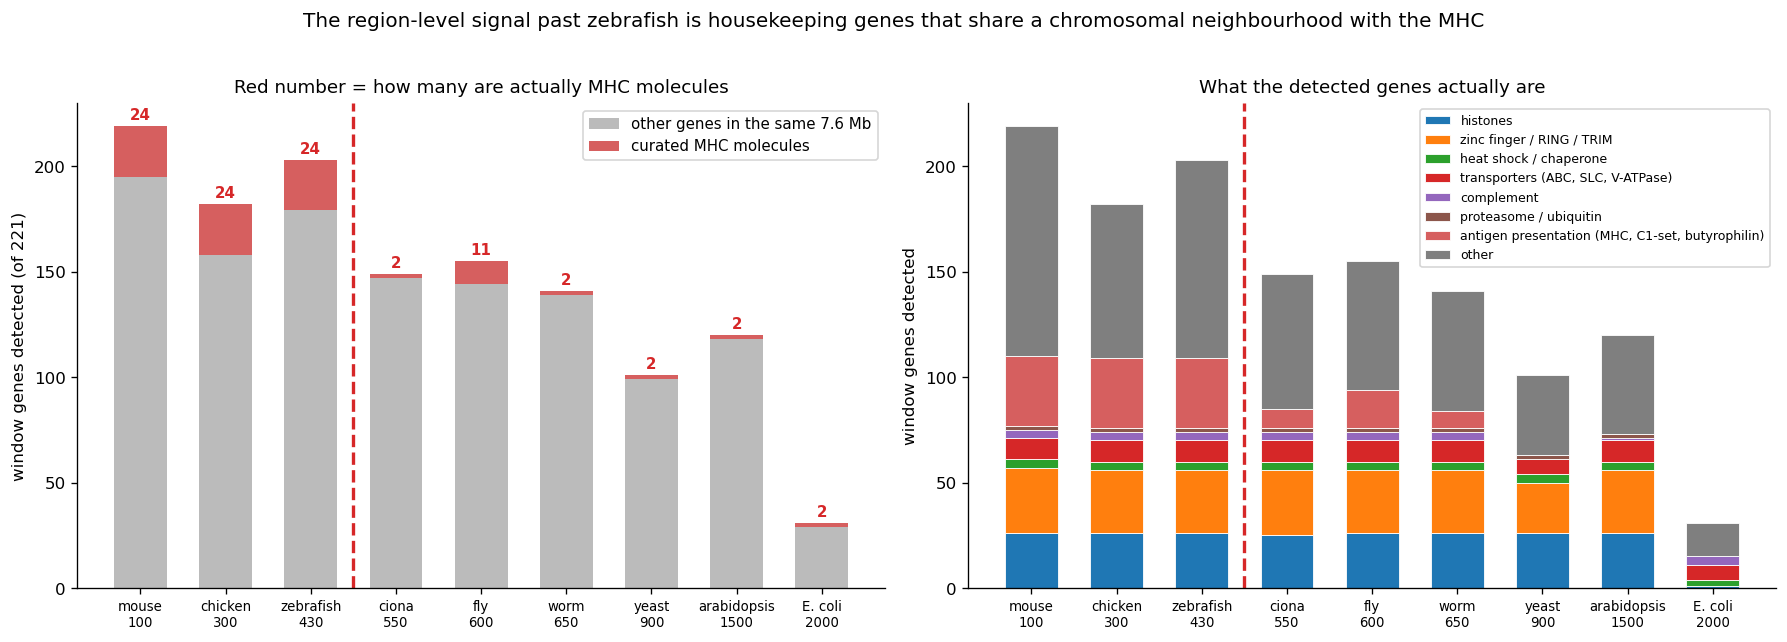

In [9]:
BASE_NO_FD = [t for t in mu.TOOL_LABELS if t not in ("kmerseek", "folddisco")]
base_arms = mu.load_gene_level().filter(pl.col("tool").is_in(BASE_NO_FD))

det = (window.select("accession", "hgnc_symbol", "hgnc_gene_group", "mhc_class")
       .join(base_arms.select("query_acc", "species", "tool", "best_cover"),
             left_on="accession", right_on="query_acc", how="left")
       .with_columns(hit=(pl.col("best_cover").fill_null(0.0) >= 0.5))
       .group_by("accession", "hgnc_symbol", "hgnc_gene_group", "mhc_class", "species")
       .agg(n_hit=pl.col("hit").sum())
       .with_columns(detected=pl.col("n_hit") >= 4))

# Coarse functional buckets by HGNC gene-group substring. Hand-made and deliberately blunt:
# the claim it supports is only "these are housekeeping families, not antigen presentation",
# which does not need a fine taxonomy. Order matters -- first match wins.
BUCKETS = [("histones", "histone"), ("zinc finger / RING / TRIM", "zinc finger|ring finger|tripartite"),
           ("heat shock / chaperone", "heat shock|chaperon"),
           ("transporters (ABC, SLC, V-ATPase)", "atp binding cassette|solute carrier|atpase"),
           ("complement", "complement|c3 and pzp"),
           ("proteasome / ubiquitin", "proteasome|ubiquitin"),
           ("antigen presentation (MHC, C1-set, butyrophilin)",
            "histocompatibility|c1-set|butyrophilin")]

def bucket(col):
    e = pl.lit("other")
    for name, pat in reversed(BUCKETS):
        e = pl.when(col.fill_null("").str.to_lowercase().str.contains(pat)).then(pl.lit(name)).otherwise(e)
    return e

det = det.with_columns(bucket=bucket(pl.col("hgnc_gene_group")))

rows = []
for sp in mu.SPECIES_ORDER:
    d = det.filter((pl.col("species") == sp) & pl.col("detected"))
    rows.append({"species": sp, "mya": mu.SPECIES_MYA[sp], "detected": d.height,
                 "curated_MHC": d.filter(pl.col("mhc_class").is_not_null()).height,
                 "which_MHC": ", ".join(sorted(
                     d.filter(pl.col("mhc_class").is_not_null())["hgnc_symbol"].drop_nulls().to_list())) or "-"})
comp = pl.DataFrame(rows)
print(f"Window genes detected by >=4 of the {len(BASE_NO_FD)} IoU-scored baselines, "
      f"out of {window.height}:")
with pl.Config(tbl_rows=12, tbl_width_chars=190, fmt_str_lengths=60):
    print(comp)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))
x = np.arange(len(mu.SPECIES_ORDER))
ax = axes[0]
other = comp["detected"] - comp["curated_MHC"]
ax.bar(x, other, 0.62, color="#bbbbbb", label="other genes in the same 7.6 Mb")
ax.bar(x, comp["curated_MHC"], 0.62, bottom=other, color="#D65F5F",
       label="curated MHC molecules")
for i, r_ in enumerate(comp.iter_rows(named=True)):
    ax.text(i, r_["detected"] + 3, str(r_["curated_MHC"]), ha="center", fontsize=9,
            color="#D62728", fontweight="bold")
ax.axvline(2.5, color="#D62728", lw=2, ls="--")
ax.set_xticks(x); ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel(f"window genes detected (of {window.height})")
ax.set_title("Red number = how many are actually MHC molecules", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
names = [b for b, _ in BUCKETS] + ["other"]
colours = plt.get_cmap("tab10")
bottom = np.zeros(len(mu.SPECIES_ORDER))
for j, b in enumerate(names):
    vals = [det.filter((pl.col("species") == sp) & pl.col("detected")
                       & (pl.col("bucket") == b)).height for sp in mu.SPECIES_ORDER]
    if not any(vals):
        continue
    ax.bar(x, vals, 0.62, bottom=bottom,
           color="#D65F5F" if b.startswith("antigen") else colours(j % 10),
           label=b, edgecolor="white", linewidth=0.5)
    bottom += np.array(vals, dtype=float)
ax.axvline(2.5, color="#D62728", lw=2, ls="--")
ax.set_xticks(x); ax.set_xticklabels([mu.SPECIES_LABELS[s] for s in mu.SPECIES_ORDER], fontsize=8)
ax.set_ylabel("window genes detected")
ax.set_title("What the detected genes actually are", fontsize=11)
ax.legend(fontsize=7.5, loc="upper right")
for a_ in axes:
    for s_ in ("right", "top"):
        a_.spines[s_].set_visible(False)
fig.suptitle("The region-level signal past zebrafish is housekeeping genes that share a "
             "chromosomal neighbourhood with the MHC", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "221_what_is_detected_distant.png", dpi=200)

print("\nTop families detected in the four most distant targets:")
for sp in ["ciona", "worm", "yeast", "ecoli"]:
    d = det.filter((pl.col("species") == sp) & pl.col("detected"))
    top = d.group_by("bucket").len().sort("len", descending=True).head(4)
    print(f"  {sp:12s} " + "; ".join(f"{b} {n}" for b, n in top.iter_rows()))